In [ ]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Load dataset
df = pd.read_csv('/content/House Price Prediction Dataset.csv')

# Display first 5 rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Information about dataset
df.info()

# Statistical summary
df.describe()

Dataset Shape: (2000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [ ]:
# Check missing values
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
# Convert categorical columns into numerical

le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,0,0,149919
1,2,4272,5,4,3,1958,0,0,0,424998
2,3,3592,2,2,3,1938,0,2,0,266746
3,4,966,4,2,2,1902,2,1,1,244020
4,5,4926,1,4,2,1975,0,1,1,636056


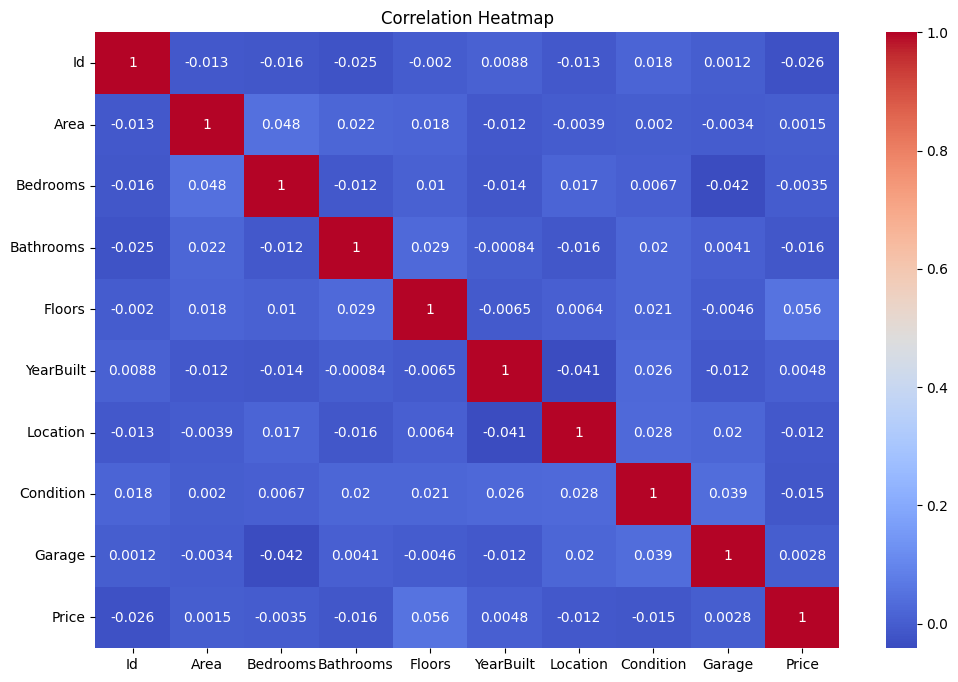

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

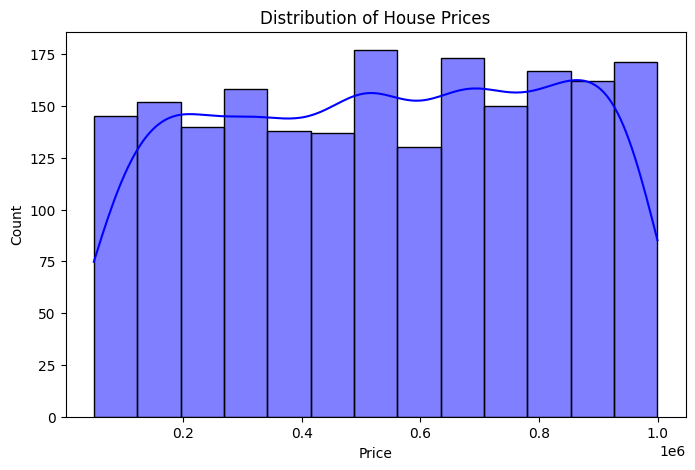

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title("Distribution of House Prices")
plt.show()

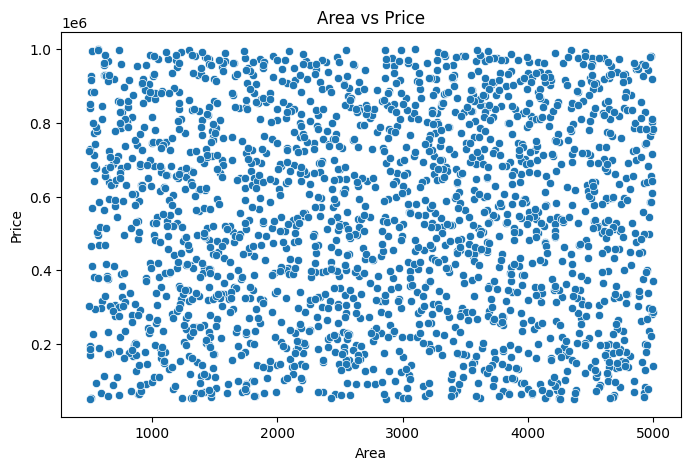

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Area'], y=df['Price'])
plt.title("Area vs Price")
plt.show()

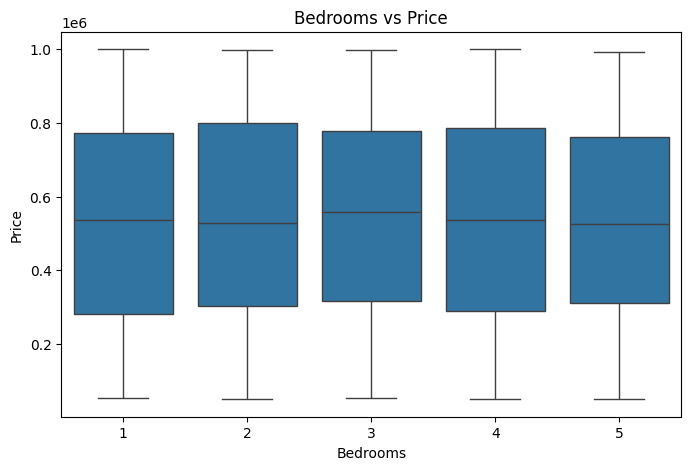

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Bedrooms'], y=df['Price'])
plt.title("Bedrooms vs Price")
plt.show()

In [ ]:
# Features
X = df.drop('Price', axis=1)

# Target variable
y = df['Price']

In [ ]:
# Split data into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# Evaluation
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression R2 Score:", lr_r2)

Linear Regression R2 Score: -0.011111291082151142


In [ ]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

# Evaluation
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree R2 Score:", dt_r2)

Decision Tree R2 Score: -1.1605771908842542


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Evaluation
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R2 Score:", rf_r2)

Random Forest R2 Score: -0.07525019966209823


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [lr_r2, dt_r2, rf_r2]
})

results

,Model,R2 Score
0,Linear Regression,-0.011111
1,Decision Tree,-1.160577
2,Random Forest,-0.075250


/tmp/ipykernel_1228/4263680369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


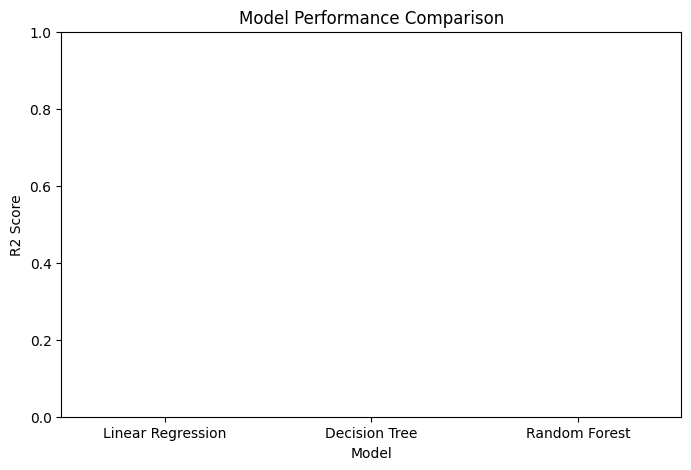

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results,
    palette='viridis'
)

plt.title("Model Performance Comparison")
plt.ylim(0,1)

plt.show()

In [ ]:
best_model = results.loc[results['R2 Score'].idxmax()]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model       Linear Regression
R2 Score            -0.011111
Name: 0, dtype: object


In [ ]:
print("MAE:", mean_absolute_error(y_test, rf_pred))

print("MSE:", mean_squared_error(y_test, rf_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

MAE: 250333.30564999997
MSE: 83653205899.49915
RMSE: 289228.63948699675


**Intro:**
This project focuses on predicting house prices using machine learning techniques. Different regression models are used to analyze and predict prices based on house features.

**Objective**
The objective of this project is to build machine learning models for predicting house prices and compare their performance.

**Dataset Description**
The dataset contains house-related information such as area, bedrooms, bathrooms, floors, location, condition, gar

**Data Cleaning & Preprocessing**
Missing values were checked and categorical columns were converted into numerical values using Label Encoding.

**Exploratory Data Analysis (EDA)**
EDA was performed to understand the relationships between variables using heatmaps, scatter plots, histograms, and b

**Machine Learning Models**
Three regression algorithms were applied:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

**Performance Comparison**
The performance of all models was compared using R² Score, MAE, MSE, and RMSE metrics.

# **conclusion:**
In this project, House Price Prediction was performed using Machine Learning techniques. The dataset was cleaned and preprocessed successfully. Exploratory Data Analysis (EDA) and different visualizations were created to understand the relationship between features and house prices.

Three machine learning algorithms were applied:
1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

After comparing the performance of all models using R² Score, Linear Regression achieved the best performance among the applied models.

Therefore, Linear Regression is considered the best-performing model for this dataset.